In [239]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, classification_report
)
from sklearn.pipeline import Pipeline

# Load the dataset
data = load_breast_cancer()

# Create a DataFrame
df_full = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target variable to the DataFrame
df_full['target'] = data.target

# drop the highly correlated features
df_full = df_full.drop(
    labels=[
        "mean perimeter", "mean area", "perimeter error",
        "area error", "worst perimeter", "worst area",
	],
    axis=1
)

# drop mean fractal dimension (very low correlation)
df_full = df_full.drop(
    labels=[
        "mean fractal dimension"
	],
    axis=1
)

df_full

,mean radius,mean texture,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,texture error,smoothness error,...,fractal dimension error,worst radius,worst texture,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,0.11840,0.27760,0.30010,0.14710,0.2419,1.0950,0.9053,0.006399,...,0.006193,25.380,17.33,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,0.08474,0.07864,0.08690,0.07017,0.1812,0.5435,0.7339,0.005225,...,0.003532,24.990,23.41,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,0.10960,0.15990,0.19740,0.12790,0.2069,0.7456,0.7869,0.006150,...,0.004571,23.570,25.53,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,0.14250,0.28390,0.24140,0.10520,0.2597,0.4956,1.1560,0.009110,...,0.009208,14.910,26.50,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,0.10030,0.13280,0.19800,0.10430,0.1809,0.7572,0.7813,0.011490,...,0.005115,22.540,16.67,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,0.11100,0.11590,0.24390,0.13890,0.1726,1.1760,1.2560,0.010300,...,0.004239,25.450,26.40,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,0.09780,0.10340,0.14400,0.09791,0.1752,0.7655,2.4630,0.005769,...,0.002498,23.690,38.25,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,0.08455,0.10230,0.09251,0.05302,0.1590,0.4564,1.0750,0.005903,...,0.003892,18.980,34.12,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,0.11780,0.27700,0.35140,0.15200,0.2397,0.7260,1.5950,0.006522,...,0.006185,25.740,39.42,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [240]:
df = df_full.filter(regex="mean|target")

# load the data
X = df.drop(labels="target", axis=1)
y = df['target']

# splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

log_reg_mean = LogisticRegression()
log_reg_mean.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [242]:
# model evaluation
y_pred_val = log_reg_mean.predict(X_val_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_val, y_pred_val)
print("On Validation Set:")
print(f"Accuracy: {accuracy:.2f}%")
print(f"AUC: {roc_auc_score(y_val, y_pred_val):.2f}")
print("-" * 50)

# test the model
y_pred = log_reg_mean.predict(X_test_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("On Test Set:")
print(f"Accuracy: {accuracy:.2f}%")
print(f"AUC: {roc_auc_score(y_test, y_pred):.2f}")

df_metrics = pd.DataFrame(
    data=["Accuracy", "AUC"],
    columns=["Metric"]
)
df_metrics['model(mean)'] = [accuracy, roc_auc_score(y_val, y_pred_val)]
df_metrics

On Validation Set:
Accuracy: 0.92%
AUC: 0.92
--------------------------------------------------
On Test Set:
Accuracy: 0.96%
AUC: 0.95


,Metric,model(mean)
0,Accuracy,0.956140
1,AUC,0.917172


Text(0.5, 1.0, 'Confusion Matrix')

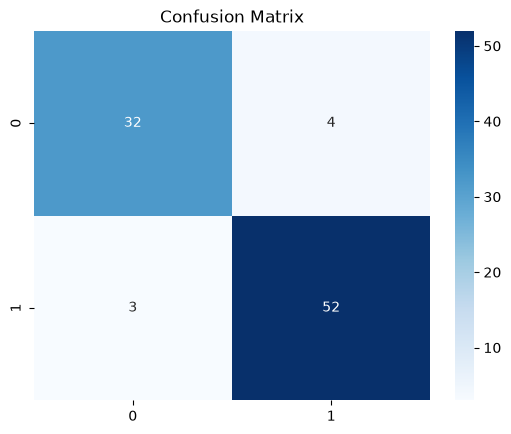

In [243]:
sns.heatmap(
    data=confusion_matrix(y_val, y_pred_val),
    annot=True,
    cmap="Blues",
)
plt.title("Confusion Matrix")

In [244]:
df_spec_mean = pd.concat([X_val, y_val], axis=1)[y_val != y_pred_val]

print("Wrong Predictions:")
df_spec_mean

Wrong Predictions:


,mean radius,mean texture,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,target
541,14.47,24.99,0.08837,0.12300,0.10090,0.03890,0.1872,1
455,13.38,30.72,0.09245,0.07426,0.02819,0.03264,0.1375,1
112,14.26,19.65,0.07837,0.22330,0.30030,0.07798,0.1704,1
171,13.43,19.63,0.09048,0.06288,0.05858,0.03438,0.1598,0
135,12.77,22.47,0.09055,0.05761,0.04711,0.02704,0.1585,0
297,11.76,18.14,0.09968,0.05914,0.02685,0.03515,0.1619,0
16,14.68,20.13,0.09867,0.07200,0.07395,0.05259,0.1586,0


In [245]:
# using features of the worst and mean
df = df_full.filter(regex="mean|worst|target")

# load the data
X = df.drop(labels="target", axis=1)
y = df['target']

# splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

log_reg_mean_worst = LogisticRegression()
log_reg_mean_worst.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [247]:
# validation
y_pred_val = log_reg_mean_worst.predict(X_val_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_val, y_pred_val)
print("On Validation Set:")
print(f"Accuracy: {accuracy:.2f}%")
print(f"AUC: {roc_auc_score(y_val, y_pred_val):.2f}")
print("-" * 50)

# test the model
y_pred = log_reg_mean_worst.predict(X_test_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("On Test Set:")
print(f"Accuracy: {accuracy:.2f}%")
print(f"AUC: {roc_auc_score(y_test, y_pred):.2f}")

df_metrics['model(mean|worst)'] = [accuracy, roc_auc_score(y_val, y_pred_val)]
df_metrics

On Validation Set:
Accuracy: 0.96%
AUC: 0.95
--------------------------------------------------
On Test Set:
Accuracy: 0.96%
AUC: 0.96


,Metric,model(mean),model(mean|worst)
0,Accuracy,0.956140,0.95614
1,AUC,0.917172,0.95404


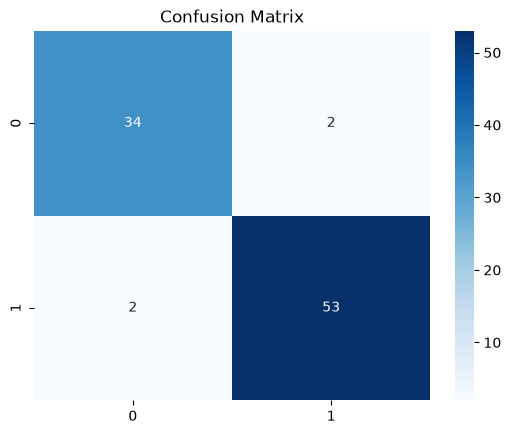

In [248]:
sns.heatmap(
    data=confusion_matrix(y_val, y_pred_val),
    annot=True,
    cmap="Blues",
)
plt.title("Confusion Matrix")
plt.show()

In [249]:
df_spec_mean_worst = pd.concat([X_val, y_val], axis=1)[y_val != y_pred_val]

print("Samples with predicted values different from actual values")
df_spec_mean_worst

Samples with predicted values different from actual values


,mean radius,mean texture,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,worst radius,worst texture,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
541,14.470,24.99,0.08837,0.12300,0.10090,0.03890,0.1872,16.22,31.73,0.1340,0.42020,0.4040,0.12050,0.3187,0.10230,1
68,9.029,17.33,0.10660,0.14130,0.31300,0.04375,0.2111,10.31,22.65,0.1482,0.43650,1.2520,0.17500,0.4228,0.11750,1
135,12.770,22.47,0.09055,0.05761,0.04711,0.02704,0.1585,14.49,33.37,0.1419,0.15230,0.2177,0.09331,0.2829,0.08067,0
297,11.760,18.14,0.09968,0.05914,0.02685,0.03515,0.1619,13.36,23.39,0.1137,0.07974,0.0612,0.07160,0.1978,0.06915,0


In [250]:
print(df_spec_mean.index)
print(df_spec_mean_worst.index)

fixed_classified_samples = [455, 112, 171, 16]

Index([541, 455, 112, 171, 135, 297, 16], dtype='int64')
Index([541, 68, 135, 297], dtype='int64')


In [251]:
print("Samples classified as Fixed")
df.iloc[fixed_classified_samples].T

Samples classified as Fixed


,455,112,171,16
mean radius,13.38000,14.26000,13.43000,14.68000
mean texture,30.72000,19.65000,19.63000,20.13000
mean smoothness,0.09245,0.07837,0.09048,0.09867
mean compactness,0.07426,0.22330,0.06288,0.07200
mean concavity,0.02819,0.30030,0.05858,0.07395
mean concave points,0.03264,0.07798,0.03438,0.05259
mean symmetry,0.13750,0.17040,0.15980,0.15860
worst radius,15.05000,15.30000,17.98000,19.07000
worst texture,41.61000,23.73000,29.87000,30.88000
worst smoothness,0.11720,0.08949,0.14010,0.14640


In [252]:
# features mean and importance
pd.DataFrame(
    data=[
        df[df["target"] == 0].mean().drop(labels="target"),
        df[df["target"] == 1].mean().drop(labels="target"),
        pd.Series(
			data=log_reg_mean_worst.coef_.ravel(),
			index=df.columns[:-1]
		),
	],
    index=["Melignant", "Benign", "coefficients"],
).T.reset_index()


,index,Melignant,Benign,coefficients
0,mean radius,17.462830,12.146524,-1.710490
1,mean texture,21.604906,17.914762,-0.832423
2,mean smoothness,0.102898,0.092478,-0.174756
3,mean compactness,0.145188,0.080085,0.634799
4,mean concavity,0.160775,0.046058,-0.586561
5,mean concave points,0.087990,0.025717,-1.221416
6,mean symmetry,0.192909,0.174186,0.108177
7,worst radius,21.134811,13.379801,-2.142442
8,worst texture,29.318208,23.515070,-0.971802
9,worst smoothness,0.144845,0.124959,-0.691686


**Analysis of Sample `455`:**

When we train our model with just features from the mean category we classified the sample wrongly as melignant. After training a model using both mean and worst features, we can see that the model classifies the sample correctly as benign.

Using the mean of any melignant features and benign, the feature importance from the logistic regression, and analyzing them we can say that: very high mean texture in this sample from the mean texture of the benign samples, makes our first model to classify this sample as melignant. So using worst features too makes our model classify the sample as benign and the model performance improved. 

Worst features that has the most impact on the model correct classification for this sample are:

- worst radius
- worst concavity
- worst concave points

Worst radius has the most impact could be interpreted as the most important feature to classify a sample.

**Summary:**

- **problem:** high mean texture in this sample from the mean texture of the benign samples
- **solution:** low worst radius, low concavity, low concave points.

**Analysis of Sample `112`:**

In Analyziing the sample we can see that the mean concavity of the sample is about 6 times higher than the mean concavity of the benign samples. This is a good sign that the model is not overfitting cause the second model currect the detection of this sample.

Because of the high mean concavity of this sample the first model wrongly classified it as melignant but adding worst features make the classification correct.

Worst features that has the most impact on the model correct classification for this sample are:

- worst radius
- worst texture

The high impcat of them on the model and the big difference in theses factors in the sample from the melignant could be the main reason that the model classify this sample as benign.

**Summary:**
- **Problem:** high mean concavity of the sample
- **Solution:** add worst features to the model (the highly effective features were worst radius and worst texture)

**Analysis of Sample `171`:**

This sample was classified wrongly as benign using the first model because by looking at its features, the first model was not able to distinguish between benign and malignant tumors well, most of the features were like benign tumors.

Adding worst features to the training and training the second model makes this possible to classify this sample as malignant. Worst features like worst radius and worst texture are very similar to the features of melignant tumors. so the feature space changed and the classification of this sample becomes possible using logistic regression.

Worst features that has the most impact on the model correct classification for this sample are:

- worst radius
- worst texture

**Summary:**
- **Problem:** The model was not able to distinguish between benign and malignant tumors well cuase all the mean features of the sample are very close to the norm of the benign tumors.
- **Solution:** Adding worst features to the training and training the second model makes this possible to classify this sample as malignant.

**Analysis of Sample `16`:**

Before adding the worst features to the training set of the model this samples was classified as benign. After adding the worst features the worst features like worst radius, worst texture, and worst concave points seem to be the most important features for the classification of this sample as melignant and add extra information to the model.

Worst features that has the most impact on the model correct classification for this sample are:

- worst radius
- worst texture
- worst concave points

**Summary:**
- **Problem:** The model wrongly classified the sample as benign.
- **Solution:** Add the worst features to the training set of the model.

In [254]:
# training the logistic regresion model on the full data
# load the data
X = df_full.drop(labels="target", axis=1)
y = df_full['target']

# splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

log_reg_mean_worst_error = LogisticRegression()
log_reg_mean_worst_error.fit(X_train_scaled, y_train)

# validation
y_pred_val = log_reg_mean_worst_error.predict(X_val_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_val, y_pred_val)
print("On Validation Set:")
print(f"Accuracy: {accuracy:.2f}%")
print(f"AUC: {roc_auc_score(y_val, y_pred_val):.2f}")
print("-" * 50)

# test the model
y_pred = log_reg_mean_worst_error.predict(X_test_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("On Test Set:")
print(f"Accuracy: {accuracy:.2f}%")
print(f"AUC: {roc_auc_score(y_test, y_pred):.2f}")

df_metrics['model(mean|worst|error)'] = [accuracy, roc_auc_score(y_val, y_pred_val)]
df_metrics

On Validation Set:
Accuracy: 0.96%
AUC: 0.95
--------------------------------------------------
On Test Set:
Accuracy: 0.96%
AUC: 0.96


,Metric,model(mean),model(mean|worst),model(mean|worst|error)
0,Accuracy,0.956140,0.95614,0.964912
1,AUC,0.917172,0.95404,0.954040


In [272]:
df = df.filter(regex='mean|worst|target')

X = df.drop(['target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

scaler = StandardScaler()
log_reg = LogisticRegression(solver="saga", max_iter=1000)

model = Pipeline([
    ('scaler', scaler),
    ('classifier', log_reg)
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['mean radius','mean texture','mean smoothness',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [273]:
y_pred_val = model.predict(X_val)

eval_report = classification_report(y_val, y_pred_val)
print(eval_report)

print(f"AUC: {roc_auc_score(y_val, y_pred_val)}")

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        36
           1       0.96      0.96      0.96        55

    accuracy                           0.96        91
   macro avg       0.95      0.95      0.95        91
weighted avg       0.96      0.96      0.96        91

AUC: 0.954040404040404


In [274]:
# model optimization
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    "classifier__C": [0.1, 1, 10, 100, 1000],
    "classifier__l1_ratio": [0.1, 0.5, 0.7, 0.9],
}

g = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

g.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/home/erfan_taherirani/miniconda3/envs/breast_cancer_project/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/erfan_taherirani/miniconda3/envs/breast_cancer_project/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/erfan_taherirani/miniconda3/envs/breast_cancer_project/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/erfan_taherirani/miniconda3/envs/breast_cancer_project/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/erfan_taherirani/miniconda3/envs/breast_cancer_project/lib/python3.12/site-packages/sklearn/li

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'classifier__l1_ratio': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.p

In [276]:
g.best_params_

{'classifier__C': 1, 'classifier__l1_ratio': 0.9}

In [286]:
g.best_estimator_["classifier"].coef_

array([[ 0.        , -0.4491394 ,  0.        ,  0.98478784,  0.        ,
        -2.69048968,  0.        , -4.07377571, -1.09004728, -0.69099055,
         0.        , -0.73190188, -0.02098453, -0.60459434,  0.        ]])